<a href="https://colab.research.google.com/github/elsieemorris-ai/benzene-exposure-tool/blob/main/CIVE442Tool1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter benzene emission rate (mg/min) [e.g. 0.5]: 0.3
Enter kitchen volume (m³) [e.g. 40]: 50
Enter ventilation rate (air changes/hour) [e.g. 1.0]: 2.5
Enter cooking duration (minutes) [e.g. 60]: 45
Enter total simulation time (minutes) [e.g. 180]: 90

--- Results ---
Peak concentration: 0.123 mg/m³
Time-integrated exposure: 0.101 mg·h/m³
Ventilation flow rate Q: 2.083 m³/min


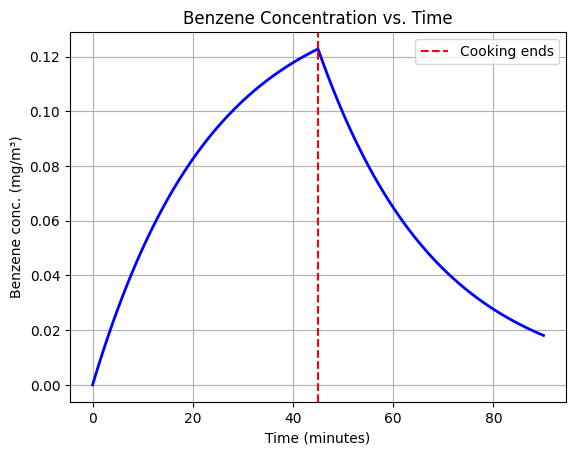

In [1]:
"""
Benzene Exposure Estimation Tool
Author: Elsie Morris
AI Collaboration: ChatGPT-assisted
Course: CIVE 442

Purpose:
Estimate indoor benzene concentrations during gas stove use using a simple box model.
"""


import math
import matplotlib.pyplot as plt

# --- USER INPUTS ---
E = float(input("Enter benzene emission rate (mg/min) [e.g. 0.5]: "))
V = float(input("Enter kitchen volume (m³) [e.g. 40]: "))
ACH = float(input("Enter ventilation rate (air changes/hour) [e.g. 1.0]: "))
t_cook = float(input("Enter cooking duration (minutes) [e.g. 60]: "))
t_total = float(input("Enter total simulation time (minutes) [e.g. 180]: "))

# --- CALCULATIONS ---
Q = ACH * V / 60  # m³/min
dt = 1
times = list(range(int(t_total) + 1))
C = [0]

for i in range(1, len(times)):
    if times[i] <= t_cook:
        dCdt = (E / V) - (Q / V) * C[-1]
    else:
        dCdt = -(Q / V) * C[-1]
    C.append(C[-1] + dCdt * dt)

C_peak = max(C)
exposure = sum(C) * dt / 60  # mg·h/m³

# --- OUTPUTS ---
print("\n--- Results ---")
print(f"Peak concentration: {C_peak:.3f} mg/m³")
print(f"Time-integrated exposure: {exposure:.3f} mg·h/m³")
print(f"Ventilation flow rate Q: {Q:.3f} m³/min")

# --- VISUALIZATION ---
plt.plot(times, C, linewidth=2, color='b')
plt.axvline(t_cook, color='r', linestyle='--', label='Cooking ends')
plt.grid(True)
plt.xlabel("Time (minutes)")
plt.ylabel("Benzene conc. (mg/m³)")
plt.title("Benzene Concentration vs. Time")
plt.legend()
plt.show()
